In [1]:
import sys 
sys.path.append("..") 
from ThirstyFLOPS.embodied import CPU_embodied, GPU_embodied, memory_embodied, SSD_embodied, HDD_embodied
from ThirstyFLOPS.operational import calculate_operational_water

polaris_CPU = CPU_embodied(location="TSMC", node = 7, yield_rate=0.875, die_area=1008, CPU_memory=0, IC_CPU=9)*560
polaris_GPU = GPU_embodied(location="TSMC", node = 7, yield_rate=0.875, die_area=826, GPU_memory=40, IC_GPU=9)*2240
polaris_memory = memory_embodied(DRAM_size = 280*1024)
polaris_SSD = SSD_embodied(8*1024*1024)
polaris_HDD = HDD_embodied(0)

embodied_water = polaris_CPU + polaris_GPU + polaris_memory + polaris_SSD + polaris_HDD
print(f"Embodied water for Polaris: {polaris_CPU} L")
#energy of polaris
with open("../HPC_util_power/polaris_util.txt", "r") as file:
    polaris_util= [float(line.strip()) for line in file if line.strip()]
polaris_tdp = 672  # kW
energy = sum(util * polaris_tdp * 24 for util in polaris_util)



Embodied water for Polaris: 191153.89439999996 L


In [2]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams.update({'mathtext.default':  'regular' })
FONTSIZE = 13
plt.rcParams["font.family"] = "serif"

In [3]:
config1 = {"wue": 6, "wetbulb": None, "energy":energy,"pue": 1.65, "energy_mix": None, "ewf": 8, "wsi_direct": 1, "wsi_indirect": 1}
config2 = {"wue": 2, "wetbulb": None, "energy":energy,"pue": 1.65, "energy_mix": None, "ewf": 1, "wsi_direct": 1, "wsi_indirect": 1}
off1,on1,_,_ = calculate_operational_water(config1)
off2,on2,_,_ = calculate_operational_water(config2)

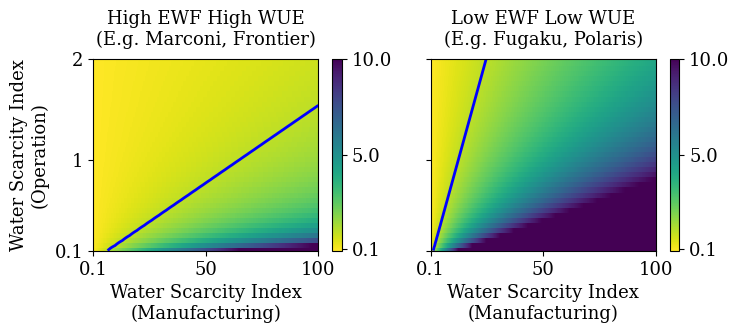

In [4]:
x_vals = np.arange(0.1, 100.1, 0.05)
y_vals = np.arange(0.1, 2.1, 0.05)
x, y = np.meshgrid(x_vals, y_vals)

def compute_ratio(x, y, emb, denom):
    return (emb * x) / (denom * y)
z1 = compute_ratio(x, y, embodied_water, energy * (1.65 * 8 + 6))  # high ewf high wue
z2 = compute_ratio(x, y, embodied_water, energy * (1.65 * 1 + 2))  # low ewf low wue
fig, axes = plt.subplots(nrows=1, ncols=2,
                         gridspec_kw={'hspace': 0.4, 'wspace': 0.2, 'bottom': 0.2,
                                      'top': 0.8, 'right': 0.995, 'left': 0.17},
                         figsize=(7.5, 3.2),
                         sharey=True)

titles = ['High EWF High WUE\n(E.g. Marconi, Frontier)', 'Low EWF Low WUE\n(E.g. Fugaku, Polaris)']
color_settings = {
    'High EWF High WUE\n(E.g. Marconi, Frontier)':    {'vmin': 0.001, 'vmax': 10, 'ticks': [0.1,5,10]},
    'Low EWF Low WUE\n(E.g. Fugaku, Polaris)':     {'vmin': 0.001, 'vmax': 10, 'ticks': [0.1, 5,10]}
}

viridis_modified = plt.cm.viridis_r

viridis_modified.set_under('white') 
for ax, z, title in zip(axes, [z1, z2], titles):
    cs = color_settings[title]
    heatmap = ax.pcolormesh(x, y, z, cmap=viridis_modified, shading='auto',
                            vmin=cs['vmin'], vmax=cs['vmax'])
    ax.set_title(title, fontsize=FONTSIZE, pad=10)
    ax.set_xlabel('Water Scarcity Index\n(Manufacturing)', fontsize=FONTSIZE)
    ax.tick_params(axis='both', which='major', labelsize=FONTSIZE)
    ax.set_xticks([0.1, 50, 100])
    ax.set_xlim(0.1, 100)
    ax.set_xticklabels(['0.1', '50', '100'])
    ax.set_yticks([0.1, 1, 2])
    ax.set_ylim(0.1, 2)
    ax.set_yticklabels(['0.1', '1', '2'])
    contour = ax.contour(x, y, z, levels=[1], colors='blue', linewidths=2)
    cbar = fig.colorbar(heatmap, ax=ax, ticks=cs['ticks'])
    cbar.ax.tick_params(labelsize=FONTSIZE)
    
axes[0].set_ylabel('Water Scarcity Index\n(Operation)', fontsize=FONTSIZE)
plt.savefig('../figures/figure4.pdf', bbox_inches='tight')
